# Machine Learning for Wildfire Danger Prediction
### Part II — ML pipeline: data loading, model training and evaluation

**Author**: Carolina Natel (Karlsruhe Institute of Technology)

*This notebook was last tested and operational on 10/09/2026. Please [report any issues](https://github.com/ecmwf-training/2026-ml-esm-training/issues).*

<!-- :::{admonition} About
:class: note, dropdown -->
This notebook was written by Carolina Natel at the Karlsruhe Institute of Technology (KIT) for the DestinE [2026 Machine Learning for Earth System Modelling Course (Applications and Future Directions)](https://learning.ecmwf.int/enrol/index.php?id=100). It walks through a complete machine learning pipeline for wildfire danger prediction over the Mediterranean, from the raw data through to an explainable Transformer model. The pipeline adapts the model and code of Becker et al. (2026) ([publication](https://iopscience.iop.org/article/10.1088/3049-4753/ae5aa0), [code](https://doi.org/10.5281/zenodo.19605470)) and uses the [Mesogeos](https://orionlab.space.noa.gr/mesogeos/) fire datacube.
<!-- ::: -->


<!-- :::{admonition} Running this notebook
:class: tip, dropdown -->
You may try to run/access this notebook on the free online platforms linked below. Please note they are not officially supported by or linked with ECMWF.

[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ecmwf-training/2026-ml-esm-training/blob/main/c3/m1/wildfire_transformer_notebook.ipynb)
[![kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ecmwf-training/2026-ml-esm-training/blob/main/c3/m1/wildfire_transformer_notebook.ipynb)
[![github](https://img.shields.io/badge/Open%20in-GitHub-black?logo=github)](https://github.com/ecmwf-training/2026-ml-esm-training/blob/main/c3/m1/wildfire_transformer_notebook.ipynb)

**Important note:**
This notebook needs the two Mesogeos CSV files (`positives.csv` and `negatives.csv`, ~210 MB in total). The data-loading cell downloads them automatically from Google Drive the first time it runs, so no manual download is needed. A GPU is optional: the model is small enough to train on CPU in a few minutes, and a GPU is detected and used automatically if one is available.
<!--
::: -->


## Introduction

In this notebook, you will go through a machine learning pipeline to predict wildfire danger in the Mediterranean using the [Mesogeos](https://orionlab.space.noa.gr/mesogeos/) dataset and an adaptation of the Becker et al. (2026) model.

1. **Load and explore** the wildfire dataset
2. **Data preprocessing**
3. **Train a Transformer model** on temporal input features (environmental data)
4. **Evaluate** performance with appropriate metrics for imbalanced data
5. **Explain** the model's decisions using eXplainable AI (XAI) with Integrated Gradients

**Dataset:** [Mesogeos](https://orionlab.space.noa.gr/mesogeos/) — a spatio-temporal fire datacube covering the Mediterranean (2006–2022) at 1 km × 1 km × 1 day resolution.

**Code base:** Built on Pauline Becker's [publication](https://iopscience.iop.org/article/10.1088/3049-4753/ae5aa0) and associated [code](https://doi.org/10.5281/zenodo.19605470).

---
## Prepare your environment

This notebook uses a small set of packages:
- `pandas` and `numpy` for data handling
- `matplotlib` and `seaborn` for plotting
- `scikit-learn` for preprocessing and evaluation metrics
- `torch` for the Transformer model and its training
- `captum` for the Integrated Gradients explainability analysis

Run the cell below to install them. This may take a minute.

In [1]:
%pip install -q -r https://raw.githubusercontent.com/ecmwf-training/2026-ml-esm-training/main/c3/m1/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 7.0 MB/s eta 0:00:00


In [2]:
# Import libraries and define global vars
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay, f1_score
)
from captum.attr import IntegratedGradients

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'All imports successful. Using device: {DEVICE}')


All imports successful. Using device: cpu


---
## Step 1 — Data Loading & Exploration

### 1.1 Get the dataset
We use pre-extracted datasets from Mesogeos, a benchmark datacube for wildfire danger prediction in the Mediterranean. The two files we need are downloaded by the next code cell from the [Mesogeos Google Drive](https://drive.google.com/drive/folders/1aRXQXVvw6hz0eYgtJDoixjPQO-_bRKz9). It's around 210 MB, and is downloaded only once.

### 1.2 About the data structure

The dataset consists of time series samples. Each sample represents a specific location (pixel) in the Mediterranean and contains **30 consecutive daily observations** of environmental variables. The task is binary classification:

- **Positive samples** (positives.csv) → a fire occurred at that location (label = 1)
- **Negative samples** (negatives.csv) → no fire occurred (label = 0)

The features fall into four physical domains:

| Domain | Variables |
|---|---|
| **Climate** | `t2m`, `lst_day`, `lst_night`, `d2m`, `rh`, `tp`, `wind_speed`, `wind_direction`, `sp`, `ssrd`, `smi` |
| **Vegetation** | `ndvi`, `lai`|
| **Topography** | `dem`, `slope`, `aspect`, `curvature` |
| **Human / Land cover** | `roads_distance`, `population`, `lc_*` (8 land cover types) |

For variable descriptions, see [Table S1 in Becker et al. 2026](https://iopscience.iop.org/article/10.1088/3049-4753/ae5aa0/data) and [Mesogeos paper](https://arxiv.org/pdf/2306.05144).

### 1.3 Load the data

Running the cell below downloads the CSV files into `./data` and loads them. If you already have the files, set `DATA_DIR` to the folder containing it and the download is skipped.


In [3]:
import os
import gdown
import pandas as pd

DATA_DIR = 'data'   # ✏️ change if your CSVs live elsewhere
os.makedirs(DATA_DIR, exist_ok=True)

# Google Drive file IDs from the Mesogeos ml_tracks/a.danger_forecasting/ folder
DRIVE_IDS = {
    'positives.csv': '1IYONBanlerMi84wedto-Vck8vmfnyVUR',
    'negatives.csv': '1qB6TjMCgpVvM04ysCZSgE-5sjJ2C9gNJ',
}

for fname, file_id in DRIVE_IDS.items():
    dest = os.path.join(DATA_DIR, fname)
    if os.path.exists(dest):
        print(f'{fname} already present — skipping download.')
    else:
        print(f'Downloading {fname} ...')
        gdown.download(id=file_id, output=dest, quiet=False)  # handles the large-file confirmation

df_pos = pd.read_csv(os.path.join(DATA_DIR, 'positives.csv'))
df_neg = pd.read_csv(os.path.join(DATA_DIR, 'negatives.csv'))

df_pos['label'] = 1
df_neg['label'] = 0

print(f'\nLoaded positives.csv {df_pos.shape} and negatives.csv {df_neg.shape}')

Downloading...
From: https://drive.google.com/uc?id=1IYONBanlerMi84wedto-Vck8vmfnyVUR
To: /content/data/positives.csv
100%|██████████| 72.8M/72.8M [00:00<00:00, 115MB/s]


Downloading...
From (original): https://drive.google.com/uc?id=1qB6TjMCgpVvM04ysCZSgE-5sjJ2C9gNJ
From (redirected): https://drive.google.com/uc?id=1qB6TjMCgpVvM04ysCZSgE-5sjJ2C9gNJ&confirm=t&uuid=fb82a5cf-d288-4d71-b3af-d206935db83d
To: /content/data/negatives.csv
100%|██████████| 145M/145M [00:00<00:00, 244MB/s]



Loaded positives.csv (257220, 36) and negatives.csv (520260, 36)


### 1.4 Explore the data

Let's look at the structure and understand what we're working with.

In [4]:
# Combine and inspect
df_all = pd.concat([df_neg, df_pos], ignore_index=True)
print("Combined dataset shape:", df_all.shape)
print("\nColumn list:")
print(df_all.columns.tolist())
print("\nFirst 3 rows:")
df_all.head(3)

Combined dataset shape: (777480, 36)

Column list:
['time', 'aspect', 'burned_areas', 'curvature', 'd2m', 'dem', 'ignition_points', 'lai', 'lst_day', 'lst_night', 'ndvi', 'rh', 'roads_distance', 'slope', 'smi', 'sp', 'ssrd', 't2m', 'tp', 'wind_direction', 'wind_speed', 'x', 'y', 'lc_agriculture', 'lc_forest', 'lc_grassland', 'lc_settlement', 'lc_shrubland', 'lc_sparse_vegetation', 'lc_water_bodies', 'lc_wetland', 'population', 'burned_area_has', 'time_idx', 'sample', 'label']

First 3 rows:


,time,aspect,burned_areas,curvature,d2m,dem,ignition_points,lai,lst_day,lst_night,...,lc_settlement,lc_shrubland,lc_sparse_vegetation,lc_water_bodies,lc_wetland,population,burned_area_has,time_idx,sample,label
0,2006-04-02,6.933952,0.0,-27.86932,285.72403,10.045106,0.0,NaN,300.38,287.24,...,0.0,0.0,0.0,0.0,0.0,510.94684,0.0,0,0,0
1,2006-04-03,6.933952,0.0,-27.86932,284.85710,10.045106,0.0,NaN,300.00,NaN,...,0.0,0.0,0.0,0.0,0.0,510.94684,0.0,1,0,0
2,2006-04-04,6.933952,0.0,-27.86932,286.72308,10.045106,0.0,NaN,299.80,284.40,...,0.0,0.0,0.0,0.0,0.0,510.94684,0.0,2,0,0


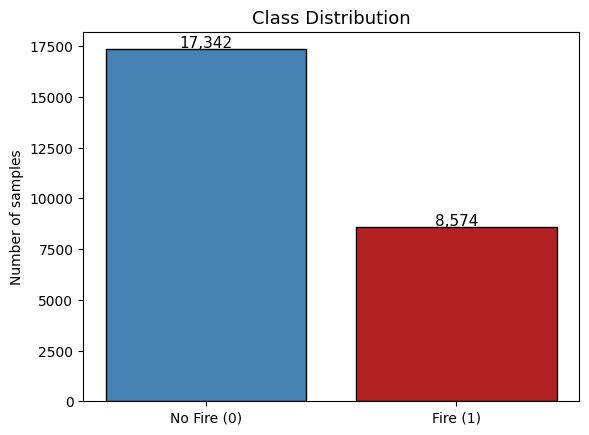

No-fire samples: 17,342
Fire samples:    8,574

  Class imbalance ratio: 2.0:1 (negatives:positives)
This is why accuracy alone is not a useful metric — we will revisit this in Step 4.


In [5]:
# Check the class balance
sample_labels = df_all.drop_duplicates(['sample', 'label'])[['sample', 'label']]
counts = sample_labels['label'].value_counts().sort_index()

n_no_fire = counts.get(0, 0)
n_fire    = counts.get(1, 0)

fig = plt.Figure(figsize=(12, 4))

# Bar chart
plt.bar(['No Fire (0)', 'Fire (1)'], [n_no_fire, n_fire],
            color=['steelblue', 'firebrick'], edgecolor='black')
plt.title('Class Distribution', fontsize=13)
plt.ylabel('Number of samples')
for i, v in enumerate([n_no_fire, n_fire]):
    plt.text(i, v + 100, f'{v:,}', ha='center', fontsize=11)
plt.show()

ratio = n_no_fire / n_fire if n_fire > 0 else float('inf')
print(f'No-fire samples: {n_no_fire:,}')
print(f'Fire samples:    {n_fire:,}')
print(f'\n  Class imbalance ratio: {ratio:.1f}:1 (negatives:positives)')
print('This is why accuracy alone is not a useful metric — we will revisit this in Step 4.')

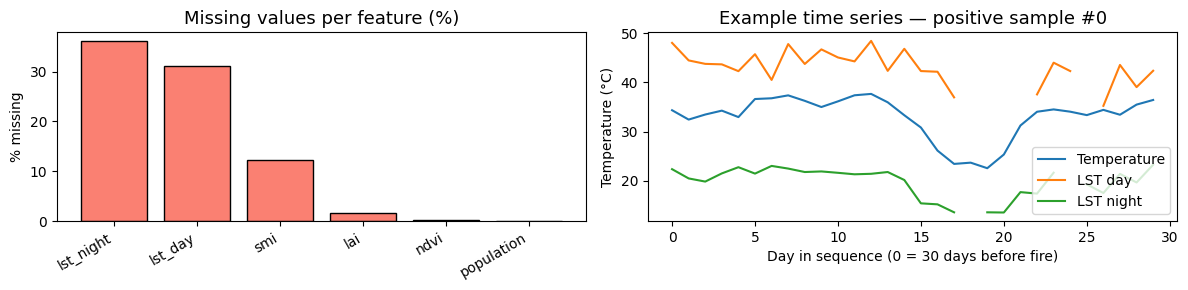

Columns with missing data: ['lst_night', 'lst_day', 'smi', 'lai', 'ndvi', 'population']


In [6]:
# Check missing values
missing = df_all.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].bar(missing.index, missing.values, color='salmon', edgecolor='black')
axes[0].set_title('Missing values per feature (%)', fontsize=13)
axes[0].set_ylabel('% missing')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

# Time series example — one positive sample
sample_id = df_pos['sample'].iloc[0]
ts = df_pos[df_pos['sample'] == sample_id]
axes[1].plot(ts['time_idx'], ts['t2m'] - 273.15, label='Temperature')
axes[1].plot(ts['time_idx'], ts['lst_day'] - 273.15, label='LST day')
axes[1].plot(ts['time_idx'], ts['lst_night'] - 273.15, label='LST night')
axes[1].set_title(f'Example time series — positive sample #{sample_id}', fontsize=13)
axes[1].set_xlabel('Day in sequence (0 = 30 days before fire)')
axes[1].set_ylabel('Temperature (°C)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Columns with missing data:", missing.index.tolist())

---
## Step 2 — Data preprocessing

### 2.1 Define features

We will use 25 environmental features. The model will receive a **[30 timesteps × 25 features]** tensor per sample.

In [7]:
# Feature groups — useful for XAI interpretation later
FEATURES_METEO     = ['t2m', 'lst_day', 'lst_night', 'd2m', 'rh', 'tp', 'wind_speed', 'wind_direction', 'sp', 'ssrd', 'smi']
FEATURES_VEG       = ['ndvi', 'lai']
FEATURES_TOPO      = ['dem', 'slope']
FEATURES_HUMAN_LAND     = ['roads_distance', 'population',
                       'lc_agriculture', 'lc_forest', 'lc_grassland', 'lc_settlement',
                       'lc_shrubland', 'lc_sparse_vegetation', 'lc_water_bodies', 'lc_wetland']

ALL_FEATURES = FEATURES_METEO + FEATURES_VEG + FEATURES_TOPO + FEATURES_HUMAN_LAND
SEQ_LEN = 30
N_FEATURES = len(ALL_FEATURES)

print(f"Total features: {N_FEATURES}")
print(f"Sequence length: {SEQ_LEN} days")
print(f"Input tensor shape per sample: ({SEQ_LEN}, {N_FEATURES})")

Total features: 25
Sequence length: 30 days
Input tensor shape per sample: (30, 25)


### 2.2 Preprocessing

1. **Split dataset into Train and Test** — using years
2. **Imputation** — Fill missing values within each time series with the average value of each variable
3. **Normalization** — StandardScaler fitted **on training data**
4. **Reshaping** — pivot from a flat table of rows into 3D tensors of shape `[n_samples, 30, 25]`

In [8]:
# Split by year (2006-2019 train, 2020-2022 test)
df_pos['YEAR'] = pd.to_datetime(df_pos['time']).dt.year.astype(str)
df_neg['YEAR'] = pd.to_datetime(df_neg['time']).dt.year.astype(str)

TRAIN_YEARS = [str(y) for y in range(2006, 2020)]
TEST_YEARS  = [str(y) for y in range(2020, 2023)]

# Split both positive and negative samples by year
pos_train = df_pos[df_pos['YEAR'].isin(TRAIN_YEARS)]
pos_test  = df_pos[df_pos['YEAR'].isin(TEST_YEARS)]
neg_train = df_neg[df_neg['YEAR'].isin(TRAIN_YEARS)]
neg_test  = df_neg[df_neg['YEAR'].isin(TEST_YEARS)]

# Combine into single train and test dataframes
df_train = pd.concat([pos_train, neg_train]).reset_index(drop=True)
df_test  = pd.concat([pos_test,  neg_test]).reset_index(drop=True)

print(f"Train: {df_train['sample'].nunique():,} samples")
print(f"Test:  {df_test['sample'].nunique():,} samples")

Train: 13,092 samples
Test:  6,412 samples


Below is a simple imputation using the column mean per variable to fill missing values:

In [9]:
def impute_series(df_train, df_test, features):
    """Fill missing values with the per-variable mean computed from the training set.
    The same training means are applied to the test set to avoid leakage."""
    df_train = df_train.copy()
    df_test = df_test.copy()

    for feat in features:
        train_mean = df_train[feat].mean()
        df_train[feat] = df_train[feat].fillna(train_mean)
        df_test[feat] = df_test[feat].fillna(train_mean)

    return df_train, df_test

# Impute missing values
df_train_filled, df_test_filled = impute_series(df_train, df_test, ALL_FEATURES)

Let's build the tensors for model training/evaluation

In [10]:
def build_tensors(df, features, seq_len=30, scaler=None, fit_scaler=False):
    """
    Convert a flat dataframe into tensors of shape (n_samples, seq_len, n_features).
    """

    df = df.copy()

    # Create unique identifier for each (label, sample) combination
    df['_uid'] = df['label'].astype(str) + '_' + df['sample'].astype(str)

    # Keep only complete samples with exactly seq_len rows
    uid_lens = df.groupby('_uid').size()
    complete_uids = uid_lens[uid_lens == seq_len].index
    df = df[df['_uid'].isin(complete_uids)].reset_index(drop=True)

    # Get n_samples from actual unique UIDs
    n_samples = df['_uid'].nunique()

    # Extract labels — one per UID
    y = df.drop_duplicates('_uid').set_index('_uid').loc[df['_uid'].unique(), 'label'].values

    # Normalize
    if fit_scaler:
        scaler = StandardScaler()
        df[features] = scaler.fit_transform(df[features])
    else:
        df[features] = scaler.transform(df[features])
    # Reshape: (n_samples * seq_len, n_features) → (n_samples, seq_len, n_features)
    X = df[features].values.reshape(n_samples, seq_len, len(features))

    if fit_scaler:
        return X, y, scaler
    return X, y

# Build tensors — scaler is fitted on train data only (no leakage)
X_train, y_train, scaler = build_tensors(df = df_train_filled, features = ALL_FEATURES, seq_len=30, fit_scaler=True)
X_test,  y_test           = build_tensors(df = df_test_filled,  features = ALL_FEATURES, seq_len=30, scaler=scaler)

print(f'X_train shape: {X_train.shape}  →  (n_samples, seq_len, n_features)')
print(f'X_test  shape: {X_test.shape}')


X_train shape: (19504, 30, 25)  →  (n_samples, seq_len, n_features)
X_test  shape: (6363, 30, 25)


### 2.3 PyTorch Dataset and DataLoader

We wrap the numpy arrays in a PyTorch `Dataset` object, which the `DataLoader` will use to serve mini-batches during training.

In [11]:
class WildfireDataset(Dataset):
    """PyTorch Dataset for wildfire time series.

    Each item is a tuple (x, y) where:
      x : FloatTensor of shape (seq_len, n_features)
      y : LongTensor scalar (0 or 1)
    """
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 128

train_dataset = WildfireDataset(X_train, y_train)
test_dataset  = WildfireDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Quick sanity check
xb, yb = next(iter(train_loader))
print(f"Batch shape — X: {xb.shape}, y: {yb.shape}")
print(f"  X dtype: {xb.dtype}, y dtype: {yb.dtype}")

Batch shape — X: torch.Size([128, 30, 25]), y: torch.Size([128])
  X dtype: torch.float32, y dtype: torch.int64


---
## Step 3 — The Transformer Model

### 3.1 Why a Transformer for wildfire prediction?

Wildfire risk is not determined by a single day's conditions — it builds up over days and weeks. Temperature, drought, and wind interact across time. Transformers are well-suited for this because their **self-attention mechanism** can directly capture dependencies between any two timesteps, regardless of distance. Unlike RNNs (LSTM, GRU), they don't process the sequence step-by-step, so they can learn patterns like "high wind on day 5 combined with drought conditions on day 25".

### 3.2 Architecture overview

```
Input: [batch, 30 days, 25 features]
       ↓
Linear projection  →  [batch, 30, d_model=64]
       ↓
Positional Encoding (learnable)
       ↓
TransformerEncoder  (N=2 layers, 4 heads each)
       ↓
Mean pooling over time  →  [batch, d_model]
       ↓
Classifier head (Linear → ReLU → Dropout → Linear)
       ↓
Output: [batch, 2]  (logits for class 0 and 1)
```

In [12]:
class WildfireTransformer(nn.Module):
    """Transformer encoder for wildfire danger classification.

    Args:
        n_features  : number of input features (25)
        seq_len     : length of the time series (30)
        d_model     : internal embedding dimension
        n_heads     : number of attention heads (must divide d_model)
        n_layers    : number of TransformerEncoder layers
        dim_ff      : feed-forward hidden size inside each encoder layer
        dropout     : dropout rate
        n_classes   : output classes (2 for binary)
    """
    def __init__(self, n_features=25, seq_len=30, d_model=64,
                 n_heads=4, n_layers=2, dim_ff=128, dropout=0.1, n_classes=2):
        super().__init__()

        # 1. Project raw features into the model's embedding space
        self.input_projection = nn.Linear(n_features, d_model)

        # 2. Learnable positional encoding — lets the model know which day each timestep is
        self.positional_encoding = nn.Embedding(seq_len, d_model)

        # 3. Transformer encoder stack
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True   # input shape: (batch, seq, features)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # 4. Classification head
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        batch_size, seq_len, _ = x.shape

        # Project features
        x = self.input_projection(x)                           # (batch, seq_len, d_model)

        # Add positional encoding
        positions = torch.arange(seq_len, device=x.device)     # (seq_len,)
        x = x + self.positional_encoding(positions)            # (batch, seq_len, d_model)

        # Transformer layers (self-attention over time)
        x = self.transformer(x)                                # (batch, seq_len, d_model)

        # Aggregate over time by averaging
        x = x.mean(dim=1)                                      # (batch, d_model)

        # Classify
        return self.classifier(x)                              # (batch, 2)


model = WildfireTransformer(n_features=N_FEATURES, seq_len=SEQ_LEN).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model architecture:\n{model}")
print(f"\nTotal trainable parameters: {total_params:,}")

Model architecture:
WildfireTransformer(
  (input_projection): Linear(in_features=25, out_features=64, bias=True)
  (positional_encoding): Embedding(30, 64)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=Fals

### 3.3 Handling class imbalance in the loss function

Remember the 2:1 imbalance we saw earlier? If we use standard cross-entropy, the model can achieve ~67% accuracy by just predicting "no fire" always — useless for our task.

The fix: **weighted cross-entropy loss** that penalizes misclassifying fires more heavily.

In [13]:
# Compute class weights inversely proportional to class frequency
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
total = n_neg + n_pos

weight_neg = total / (2 * n_neg)
weight_pos = total / (2 * n_pos)
class_weights = torch.FloatTensor([weight_neg, weight_pos]).to(DEVICE)

print(f"Class weights — no fire: {weight_neg:.3f}, fire: {weight_pos:.3f}")
print("(Higher weight for fire class = bigger penalty for missing a fire)")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

Class weights — no fire: 0.747, fire: 1.512
(Higher weight for fire class = bigger penalty for missing a fire)


### 3.4 Training loop

In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        preds = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += len(y_batch)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = logits.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)
            all_preds.append(preds.cpu()); all_probs.append(probs.cpu()); all_labels.append(y_batch.cpu())
    preds  = torch.cat(all_preds).numpy()
    probs  = torch.cat(all_probs).numpy()
    labels = torch.cat(all_labels).numpy()
    return total_loss / total, correct / total, preds, probs, labels


# ── Training ─────────────────────────────────────────────────────────────────
N_EPOCHS = 10
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_f1, best_state = 0.0, None

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | {'Val Acc':>7} | {'Val F1':>7}")
print("-" * 50)

for epoch in range(1, N_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_preds, val_probs, val_labels = evaluate(model, test_loader, criterion, DEVICE)
    val_f1 = f1_score(val_labels, val_preds, zero_division=0)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    print(f"{epoch:>5} | {train_loss:>10.4f} | {val_loss:>8.4f} | {val_acc:>7.3f} | {val_f1:>7.3f}")

print(f"\n✅ Training complete. Best validation F1: {best_f1:.3f}")
model.load_state_dict(best_state)  # restore best checkpoint

Epoch | Train Loss | Val Loss | Val Acc |  Val F1
--------------------------------------------------
    1 |     0.4637 |   0.5087 |   0.767 |   0.707
    2 |     0.3665 |   0.3760 |   0.824 |   0.764
    3 |     0.3410 |   0.4475 |   0.796 |   0.746
    4 |     0.3282 |   0.3939 |   0.820 |   0.755
    5 |     0.3200 |   0.4224 |   0.816 |   0.749
    6 |     0.3028 |   0.3353 |   0.851 |   0.785
    7 |     0.2940 |   0.3736 |   0.841 |   0.773
    8 |     0.2916 |   0.3418 |   0.849 |   0.784
    9 |     0.2848 |   0.3484 |   0.846 |   0.779
   10 |     0.2818 |   0.3457 |   0.846 |   0.783

✅ Training complete. Best validation F1: 0.785


<All keys matched successfully>

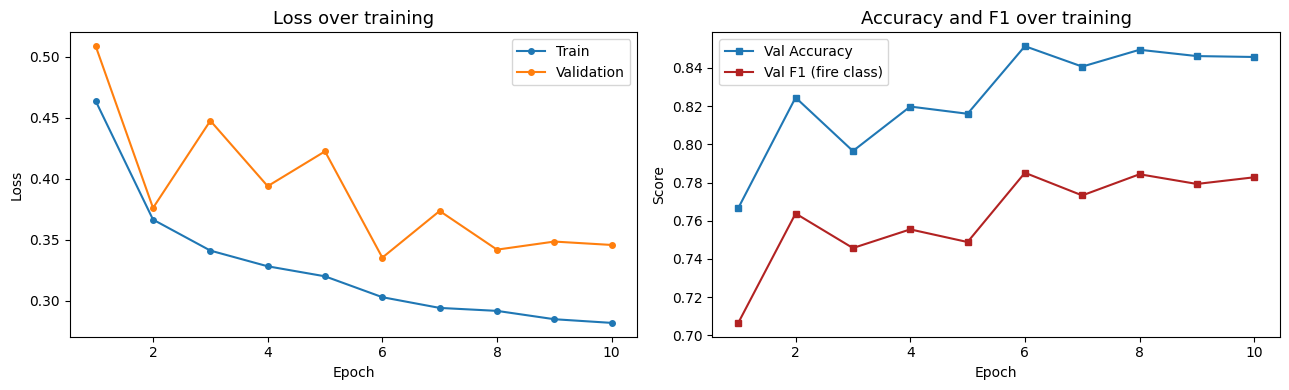

In [15]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs = range(1, N_EPOCHS + 1)

axes[0].plot(epochs, history['train_loss'], label='Train', marker='o', markersize=4)
axes[0].plot(epochs, history['val_loss'], label='Validation', marker='o', markersize=4)
axes[0].set_title('Loss over training', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(epochs, history['val_acc'], label='Val Accuracy', marker='s', markersize=4)
axes[1].plot(epochs, history['val_f1'], label='Val F1 (fire class)', marker='s', markersize=4, color='firebrick')
axes[1].set_title('Accuracy and F1 over training', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score'); axes[1].legend()

plt.tight_layout()
plt.show()

---
## 📊 Step 4 — Model Evaluation

### 4.1 Why accuracy is not enough

With ~2:1 class imbalance, a model that always predicts "no fire" would score ~67% accuracy — yet be completely useless.

For wildfire detection we care about:

| Metric | What it measures | Why it matters here |
|---|---|---|
| **F1-score** | Harmonic mean of precision & recall | Balanced view of fire detection |
| **Recall (fire)** | % of actual fires correctly detected | Missing a fire is catastrophic |
| **Precision (fire)** | % of fire predictions that are real | Avoid too many false alarms |
| **ROC-AUC** | Separability across all thresholds | Overall discrimination power |
| **PR-AUC** | Area under precision-recall curve | Better than ROC-AUC under imbalance |

In [16]:
# Final evaluation on test set
_, _, test_preds, test_probs, test_labels = evaluate(model, test_loader, criterion, DEVICE)

print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(test_labels, test_preds, target_names=['No Fire', 'Fire']))

roc_auc = roc_auc_score(test_labels, test_probs)
pr_auc  = average_precision_score(test_labels, test_probs)
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     No Fire       0.91      0.87      0.89      4250
        Fire       0.75      0.82      0.79      2113

    accuracy                           0.85      6363
   macro avg       0.83      0.84      0.84      6363
weighted avg       0.86      0.85      0.85      6363

ROC-AUC  : 0.9241
PR-AUC   : 0.8631


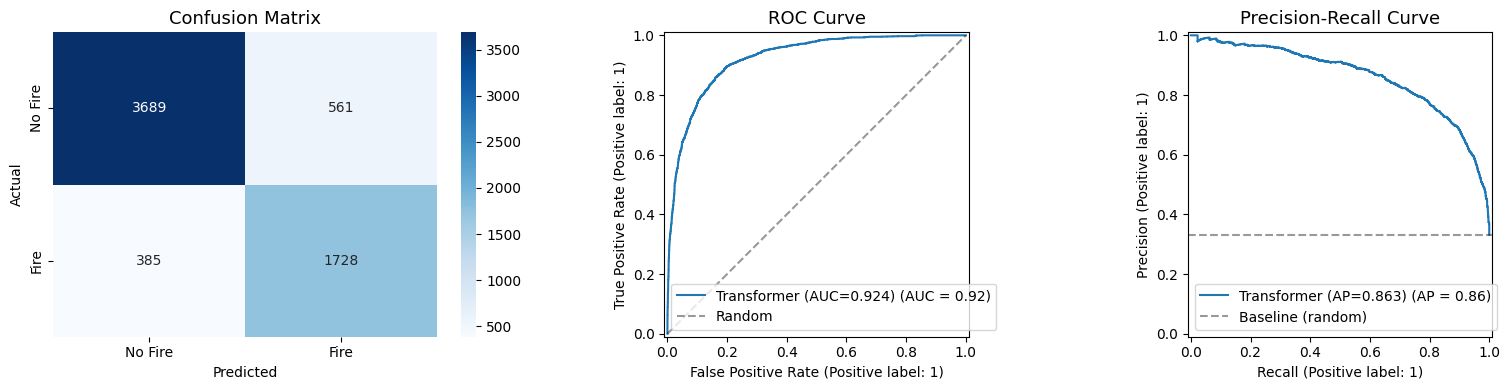

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Fire', 'Fire'], yticklabels=['No Fire', 'Fire'])
axes[0].set_title('Confusion Matrix', fontsize=13)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# ROC curve
RocCurveDisplay.from_predictions(test_labels, test_probs, ax=axes[1], name=f'Transformer (AUC={roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].legend()

# Precision-Recall curve
PrecisionRecallDisplay.from_predictions(test_labels, test_probs, ax=axes[2], name=f'Transformer (AP={pr_auc:.3f})')
axes[2].axhline(y=test_labels.mean(), color='k', linestyle='--', alpha=0.4, label='Baseline (random)')
axes[2].set_title('Precision-Recall Curve', fontsize=13)
axes[2].legend()

plt.tight_layout()
plt.show()

### 🤔 Discussion

Look at the confusion matrix and classification report:

- **False Negatives** (fires predicted as no-fire) — they represent missed fire warnings
- **False Positives** (no-fire predicted as fire) cause unnecessary alerts
- The PR curve is more informative than the ROC curve under class imbalance — a random classifier traces a horizontal line at the positive class frequency (~0.33), not at 0.5 as in the ROC space

> **Exercise:** How would you adjust the classification threshold to increase recall at the cost of precision? What does `test_probs > 0.3` give compared to `test_probs > 0.5`? And how does that decision impact on model use?

In [18]:
# ✏️ Exercise — try different thresholds
for threshold in [0.3, 0.4, 0.5, 0.6]:
    preds_thresh = (test_probs >= threshold).astype(int)
    f1 = f1_score(test_labels, preds_thresh, zero_division=0)
    from sklearn.metrics import recall_score, precision_score
    rec = recall_score(test_labels, preds_thresh, zero_division=0)
    prec = precision_score(test_labels, preds_thresh, zero_division=0)
    print(f"Threshold {threshold:.1f} → Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")

Threshold 0.3 → Precision: 0.667 | Recall: 0.908 | F1: 0.769
Threshold 0.4 → Precision: 0.712 | Recall: 0.870 | F1: 0.783
Threshold 0.5 → Precision: 0.755 | Recall: 0.818 | F1: 0.785
Threshold 0.6 → Precision: 0.794 | Recall: 0.764 | F1: 0.779


---
##  Bonus — Explainability with Integrated Gradients

### 5.1 What is Integrated Gradients?

Integrated Gradients (IG) is an attribution method that answers: *"which features, at which timesteps, contributed most to this prediction?"*

The idea is to interpolate between a **baseline input** (e.g. all zeros = no signal) and the **actual input**, computing the gradient of the model's output at each step along this path. Summing these gradients gives the attribution for each input dimension.

$$\text{IG}_i(x) = (x_i - x_i') \times \int_{\alpha=0}^{1} \frac{\partial F(x' + \alpha(x - x'))}{\partial x_i} d\alpha$$

- $x$ = actual input, $x'$ = baseline
- A **positive attribution** → feature pushed the model toward predicting fire
- A **negative attribution** → feature pushed against fire prediction

We use [Captum](https://captum.ai/), PyTorch's XAI library.

In [19]:
# Wrap model for Captum — it expects outputs as a single value, not logits
class ModelWrapper(nn.Module):
    """Returns P(fire) = softmax probability for class 1."""
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return torch.softmax(self.model(x), dim=1)[:, 1:2]  # shape: (batch, 1)

model.eval()
wrapped_model = ModelWrapper(model)
ig = IntegratedGradients(wrapped_model)

print("✅ Integrated Gradients ready.")

✅ Integrated Gradients ready.


In [20]:
# Select a subset of positive (fire) test samples for analysis
fire_idx = np.where(test_labels == 1)[0][:50]  # first 50 fire samples
X_fire = torch.FloatTensor(X_test[fire_idx]).to(DEVICE)
baseline = torch.zeros_like(X_fire)  # zero baseline

# Compute attributions
attributions, delta = ig.attribute(
    inputs=X_fire,
    baselines=baseline,
    target=0,           # target output index (we use the single P(fire) output)
    return_convergence_delta=True,
    n_steps=50
)

attributions_np = attributions.detach().cpu().numpy()  # (n_samples, seq_len, n_features)
print(f"Attribution tensor shape: {attributions_np.shape}")
print(f"Mean convergence delta: {delta.mean().item():.6f}  (should be close to 0)")

Attribution tensor shape: (50, 30, 25)
Mean convergence delta: 0.000402  (should be close to 0)


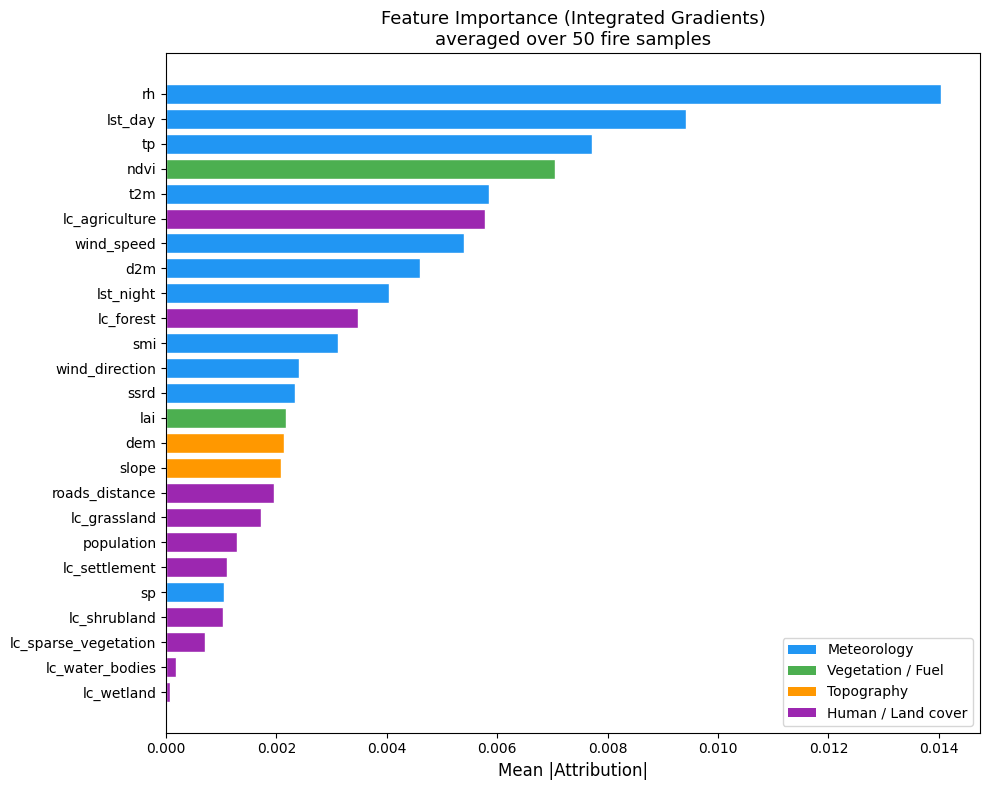

In [22]:
# ── Global feature importance ─────────────────────────────────────────────────
# Average absolute attribution across all fire samples and all timesteps
mean_attr = np.abs(attributions_np).mean(axis=(0, 1))  # (n_features,)

feature_importance = pd.Series(mean_attr, index=ALL_FEATURES).sort_values(ascending=True)

# Color by domain
domain_colors = {}
for f in FEATURES_METEO:  domain_colors[f] = '#2196F3'  # blue
for f in FEATURES_VEG:    domain_colors[f] = '#4CAF50'  # green
for f in FEATURES_TOPO:   domain_colors[f] = '#FF9800'  # orange
for f in FEATURES_HUMAN_LAND:  domain_colors[f] = '#9C27B0'  # purple

colors = [domain_colors.get(f, 'gray') for f in feature_importance.index]

plt.figure(figsize=(10, 8))
bars = plt.barh(feature_importance.index, feature_importance.values, color=colors, edgecolor='white')
plt.xlabel('Mean |Attribution|', fontsize=12)
plt.title('Feature Importance (Integrated Gradients)\naveraged over 50 fire samples', fontsize=13)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2196F3', label='Meteorology'),
    Patch(facecolor='#4CAF50', label='Vegetation / Fuel'),
    Patch(facecolor='#FF9800', label='Topography'),
    Patch(facecolor='#9C27B0', label='Human / Land cover'),
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

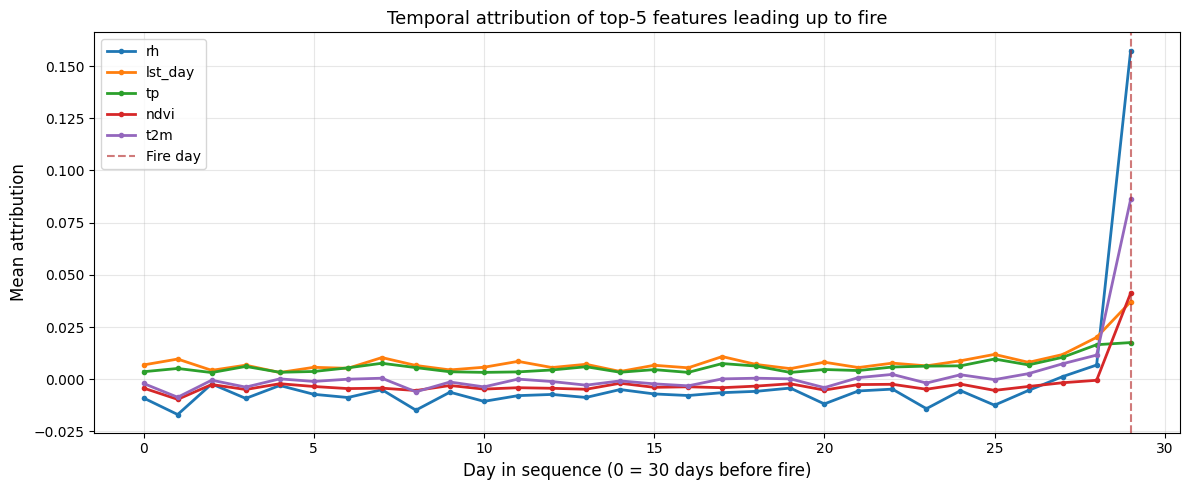

In [23]:
# ── Temporal attribution — how importance evolves over the 30-day window ──────
# Pick the top 5 most important features from the chart above
top5_features = feature_importance.sort_values(ascending=False).head(5).index.tolist()
top5_idx = [ALL_FEATURES.index(f) for f in top5_features]

# Average attribution per timestep for each top feature
# attributions_np shape: (n_samples, seq_len, n_features)
temporal_attr = attributions_np[:, :, top5_idx].mean(axis=0)  # (seq_len, 5)

plt.figure(figsize=(12, 5))
days = np.arange(SEQ_LEN)
for i, feat in enumerate(top5_features):
    plt.plot(days, temporal_attr[:, i], label=feat, linewidth=2, marker='o', markersize=3)

plt.axvline(x=SEQ_LEN - 1, color='firebrick', linestyle='--', alpha=0.6, label='Fire day')
plt.xlabel('Day in sequence (0 = 30 days before fire)', fontsize=12)
plt.ylabel('Mean attribution', fontsize=12)
plt.title('Temporal attribution of top-5 features leading up to fire', fontsize=13)
plt.legend(fontsize=10, loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

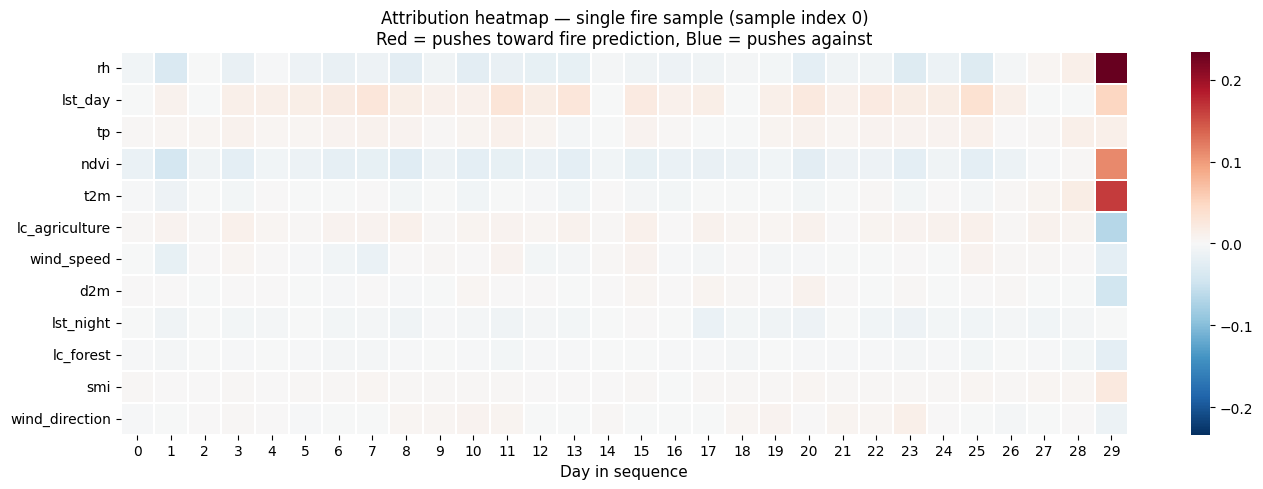

In [24]:
# ── Attribution heatmap for a single fire sample ──────────────────────────────
# Pick one sample to inspect in detail
sample_idx = 0
sample_attr = attributions_np[sample_idx]  # (seq_len, n_features)

# Show only top 12 features for readability
top12 = feature_importance.sort_values(ascending=False).head(12).index.tolist()
top12_idx = [ALL_FEATURES.index(f) for f in top12]

plt.figure(figsize=(14, 5))
heatmap_data = sample_attr[:, top12_idx].T  # (12, 30)
vmax = np.abs(heatmap_data).max()
sns.heatmap(heatmap_data,
            xticklabels=np.arange(SEQ_LEN),
            yticklabels=top12,
            cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
            linewidths=0.3, linecolor='white')
plt.xlabel('Day in sequence', fontsize=11)
plt.title(f'Attribution heatmap — single fire sample (sample index {sample_idx})\n'
          'Red = pushes toward fire prediction, Blue = pushes against', fontsize=12)
plt.tight_layout()
plt.show()

### 🤔 Discussion — Interpretability

Look at the feature importance chart and the temporal attribution plot:

- Do the most important features make physical sense? (i.e., in comparison to well-known fire drivers?)
- What do the temporal attribution and attribution heatmap for one sample show?

> **Exercise:** Re-run the IG analysis on a **negative** sample (no fire). Do the attribution patterns differ? What does this tell you about what the model learned?

In [25]:
# ✏️ Exercise — attributions for no-fire samples
nofire_idx = np.where(test_labels == 0)[0][:50]
X_nofire = torch.FloatTensor(X_test[nofire_idx]).to(DEVICE)
baseline_nofire = torch.zeros_like(X_nofire)

attr_nofire, _ = ig.attribute(
    inputs=X_nofire,
    baselines=baseline_nofire,
    target=0,
    return_convergence_delta=True,
    n_steps=50
)
attr_nofire_np = attr_nofire.detach().cpu().numpy()

mean_attr_nofire = np.abs(attr_nofire_np).mean(axis=(0, 1))
feat_imp_nofire  = pd.Series(mean_attr_nofire, index=ALL_FEATURES).sort_values(ascending=False)

# Compare top features: fire vs no-fire
comparison = pd.DataFrame({
    'Fire samples':    feature_importance.sort_values(ascending=False),
    'No-fire samples': feat_imp_nofire
})
print("Top 10 features by attribution — Fire vs No-Fire samples:")
print(comparison.head(10).round(5))

Top 10 features by attribution — Fire vs No-Fire samples:
                      Fire samples  No-fire samples
d2m                        0.00461          0.00297
dem                        0.00214          0.00074
lai                        0.00218          0.00077
lc_agriculture             0.00577          0.00100
lc_forest                  0.00347          0.00101
lc_grassland               0.00172          0.00032
lc_settlement              0.00111          0.00049
lc_shrubland               0.00103          0.00038
lc_sparse_vegetation       0.00070          0.00028
lc_water_bodies            0.00019          0.00005


---
## ✅ Summary

In this notebook you built a complete ML pipeline for wildfire danger prediction:

| Step | What you did |
|---|---|
| **Data Loading and Exploration** | Combined positive/negative samples, explored class imbalance and missing values |
| **Data Preprocessing** | Split train/test, imputation of missing values, normalization, tensor reshaping |
| **Model** | Transformer encoder |
| **Training** | Weighted cross-entropy loss, Adam optimizer, early stopping via best F1 |
| **Evaluation** | Accuracy, precision, recall, F1-score, ROC, Precision-Recall Curve |
| **XAI** | Integrated Gradients — feature importance, temporal dynamics, single-sample heatmaps |

### Next steps (optional)
- Tune hyperparameters: `d_model`, `n_heads`, `n_layers`, `dropout`, `learning rate`